# Research Insights and Robustness Checks

This notebook explores the strongest relationships between music-listening habits, preferences, and self-reported anxiety outcomes. We also conduct robustness checks to evaluate the stability of our findings.



## 1. Load Cleaned Dataset



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/processed/mxmh_cleaned.csv")
print("Cleaned dataset dimensions:", df.shape)



Cleaned dataset dimensions: (736, 31)


## 2. Demographics vs. Anxiety: Age vs. Anxiety

### What variables are compared?
`Age` (continuous numerical feature) vs. `Anxiety` (continuous target score from 0 to 10).

### Why interesting?
Age is a standard control demographic. Understanding how anxiety changes across life stages helps identify if younger cohorts report higher anxiety.

### Analysis & Visualization:



Correlation between Age and Anxiety: -0.1770


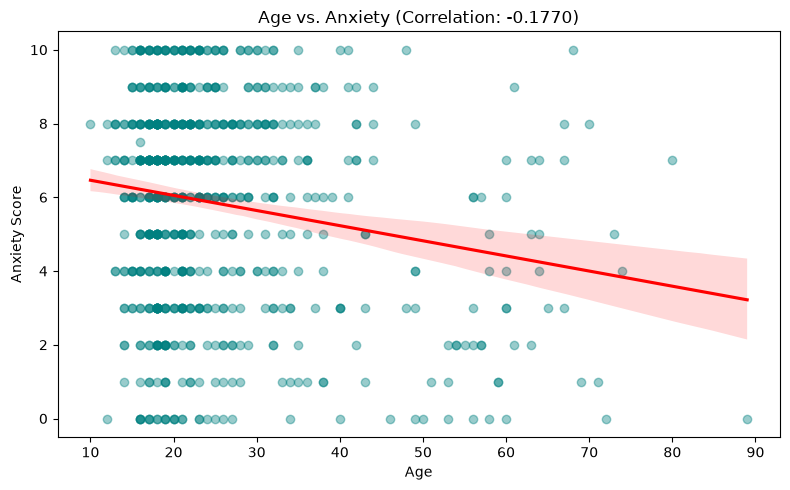

In [2]:
corr_age_anxiety = df["Age"].corr(df["Anxiety"])
print(f"Correlation between Age and Anxiety: {corr_age_anxiety:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Age", y="Anxiety", scatter_kws={"alpha":0.4, "color":"teal"}, line_kws={"color":"red"})
plt.title(f"Age vs. Anxiety (Correlation: {corr_age_anxiety:.4f})")
plt.xlabel("Age")
plt.ylabel("Anxiety Score")
plt.tight_layout()
plt.savefig("../docs/figures/insight_age_vs_anxiety.png", dpi=120)
plt.show()



## 3. Music Behavior vs. Anxiety: Hours per day vs. Anxiety

### What variables are compared?
`Hours per day` (continuous music listening hours) vs. `Anxiety` (continuous target score).

### Why interesting?
Our best-performing Decision Tree (`max_depth=3`) relied heavily on `Hours per day` to split samples. We want to check the strength and shape of this relationship.

### Analysis & Visualization:



Correlation between Hours per day and Anxiety: 0.0493


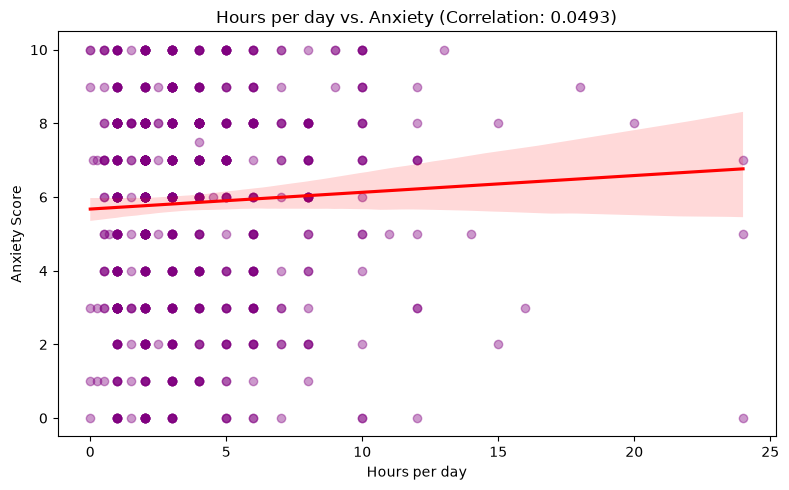

In [3]:
corr_hours_anxiety = df["Hours per day"].corr(df["Anxiety"])
print(f"Correlation between Hours per day and Anxiety: {corr_hours_anxiety:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Hours per day", y="Anxiety", scatter_kws={"alpha":0.4, "color":"purple"}, line_kws={"color":"red"})
plt.title(f"Hours per day vs. Anxiety (Correlation: {corr_hours_anxiety:.4f})")
plt.xlabel("Hours per day")
plt.ylabel("Anxiety Score")
plt.tight_layout()
plt.savefig("../docs/figures/insight_hours_vs_anxiety.png", dpi=120)
plt.show()



## 4. Subjective Music Perception vs. Anxiety: Music effects vs. Anxiety

### What variables are compared?
`Music effects` (categorical perception: Improve, No effect, Worsen) vs. `Anxiety` (continuous target).

### Why interesting?
This is a subjective context check. We want to see how baseline anxiety averages compare across respondents' perceived music effects.

### Analysis & Visualization:



  Music effects   Anxiety
0       Improve  6.028182
1     No effect  5.124260
2        Worsen  6.764706


C:\Users\aksha\AppData\Local\Temp\ipykernel_30916\3813685491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Music effects", y="Anxiety", palette="Set2")


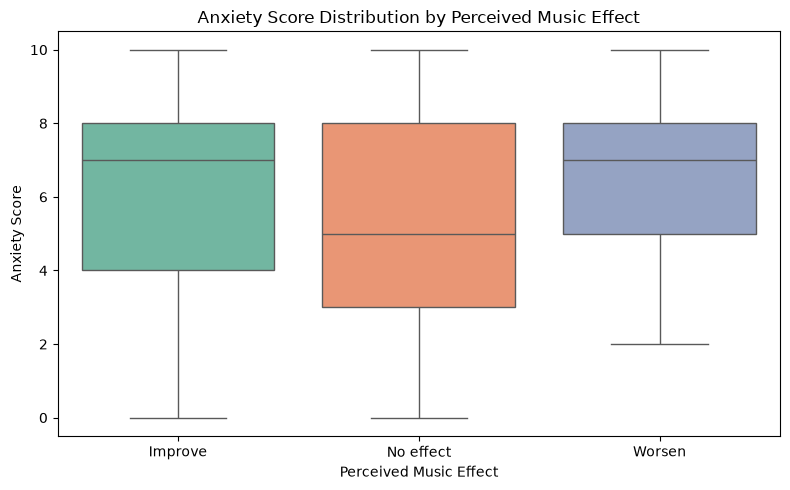

In [4]:
group_effects = df.groupby("Music effects")["Anxiety"].mean().reset_index()
print(group_effects)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Music effects", y="Anxiety", palette="Set2")
plt.title("Anxiety Score Distribution by Perceived Music Effect")
plt.xlabel("Perceived Music Effect")
plt.ylabel("Anxiety Score")
plt.tight_layout()
plt.savefig("../docs/figures/insight_effects_vs_anxiety.png", dpi=120)
plt.show()



## 5. Robustness Checks

### Robustness Check 1: Exclude Extreme Listening Hours (>12 hours/day)
* **WHAT**: Check if dropping participants listening to music >12 hours/day alters the correlation with Anxiety.
* **WHY**: Extreme values (outliers) can dominate correlation estimates.



In [5]:
df_sub_hours = df[df["Hours per day"] <= 12]
corr_sub_hours = df_sub_hours["Hours per day"].corr(df_sub_hours["Anxiety"])
print(f"Overall correlation (N={len(df)}): {corr_hours_anxiety:.4f}")
print(f"Subgroup correlation hours <= 12 (N={len(df_sub_hours)}): {corr_sub_hours:.4f}")



Overall correlation (N=736): 0.0493
Subgroup correlation hours <= 12 (N=726): 0.0730


### Robustness Check 2: Exclude Elderly Participants (Age > 70)
* **WHAT**: Check if dropping elderly participants alters the correlation between Age and Anxiety.
* **WHY**: A small number of older individuals can act as high-leverage points in a linear correlation.



In [6]:
df_sub_age = df[df["Age"] <= 70]
corr_sub_age = df_sub_age["Age"].corr(df_sub_age["Anxiety"])
print(f"Overall correlation (N={len(df)}): {corr_age_anxiety:.4f}")
print(f"Subgroup correlation age <= 70 (N={len(df_sub_age)}): {corr_sub_age:.4f}")



Overall correlation (N=736): -0.1770
Subgroup correlation age <= 70 (N=730): -0.1522


### Robustness Check 3: Imputation Audit (BPM Imputation vs. Row Deletion)
* **WHAT**: Compare the correlation between BPM and Anxiety in the cleaned (median-imputed) dataset vs. raw dataset after dropping BPM nulls.
* **WHY**: Imputing 107 missing BPM values with the median could artificially compress the covariance.



In [7]:
# Load raw to audit BPM drop
df_raw = pd.read_csv("../data/raw/mxmh_survey_results.csv")
df_raw_bpm = df_raw[(df_raw["BPM"] >= 40) & (df_raw["BPM"] <= 220)].dropna(subset=["BPM", "Anxiety"])

corr_clean_bpm = df["BPM"].corr(df["Anxiety"])
corr_raw_bpm = df_raw_bpm["BPM"].corr(df_raw_bpm["Anxiety"])

print(f"Cleaned (Imputed median) correlation (N={len(df)}): {corr_clean_bpm:.4f}")
print(f"Raw (Dropped NaNs) correlation (N={len(df_raw_bpm)}): {corr_raw_bpm:.4f}")



Cleaned (Imputed median) correlation (N=736): 0.0512
Raw (Dropped NaNs) correlation (N=621): 0.0557
